1.How many tennis players are included in the dataset? 

In [42]:
import pandas as pd
import pyarrow.parquet as pq
import glob
import os

base_path = '../data/input/tennis_data/'
all_files = glob.glob(os.path.join(base_path, '**/*.parquet'), recursive=True)

dfs = []

for i, file in enumerate(all_files[:10000]):
    try:
        schema = pq.read_schema(file)
        if 'player_id' in schema.names:
            df = pd.read_parquet(file, columns=['player_id'])
            dfs.append(df)
    except Exception as e:
        print(f"Skipped {file}: {e}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.to_parquet('players_combined.parquet')


df = pd.read_parquet('players_combined.parquet')
num_players = df['player_id'].dropna().nunique()
print("Unique players:", num_players)

Unique players: 673


2. What is the average height of the players? 

100%|██████████| 120030/120030 [02:15<00:00, 885.14it/s] 


Average height: 1.82 cm


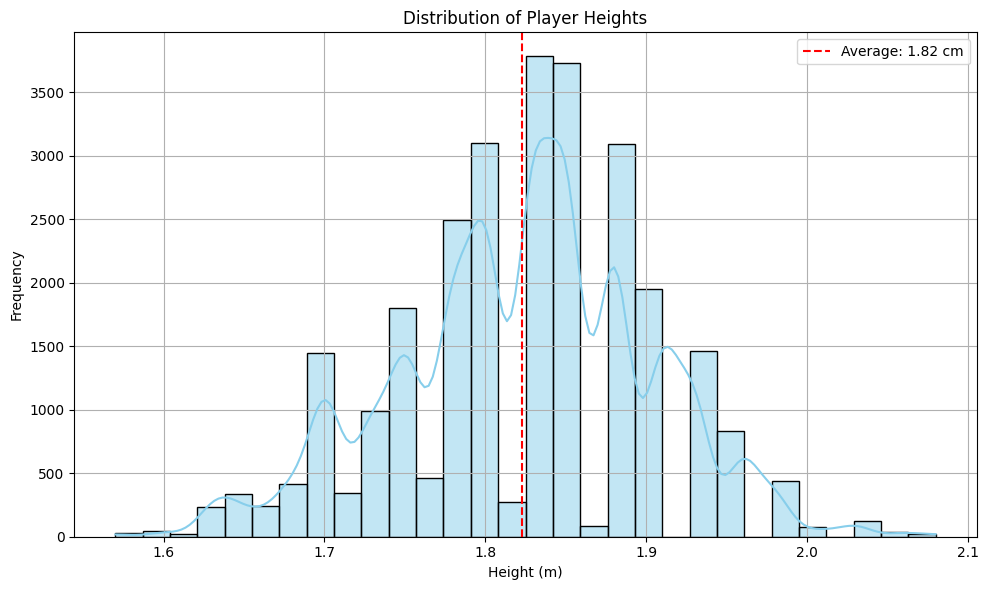

In [58]:
import pandas as pd
import pyarrow.parquet as pq
from glob import glob
from tqdm import tqdm
import os
import seaborn as sns
import matplotlib.pyplot as plt

away_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/away*.parquet')
home_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/home*.parquet')

all_files = away_files + home_files

heights = []

for file in tqdm(all_files):
    try:
        parquet_file = pq.ParquetFile(file)
        column_names = parquet_file.schema.names
        
        if 'height' in column_names:
            df = pd.read_parquet(file, columns=['height'])
            heights.extend(df['height'].dropna().tolist())
            
    except Exception as e:
        print(f"Error reading file {file}: {e}")

if heights:
    average_height = sum(heights) / len(heights)
    print(f"Average height: {average_height:.2f} m")
    plt.figure(figsize=(10, 6))
    sns.histplot(heights, bins=30, kde=True, color="skyblue")
    plt.axvline(average_height, color='red', linestyle='--', label=f'Average: {average_height:.2f} m')
    plt.title('Distribution of Player Heights')
    plt.xlabel('Height (m)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No height data found.")


3. Which player has the highest number of wins? 

100%|██████████| 35053/35053 [03:16<00:00, 178.04it/s]


Player with most wins: Popko, Dmitry


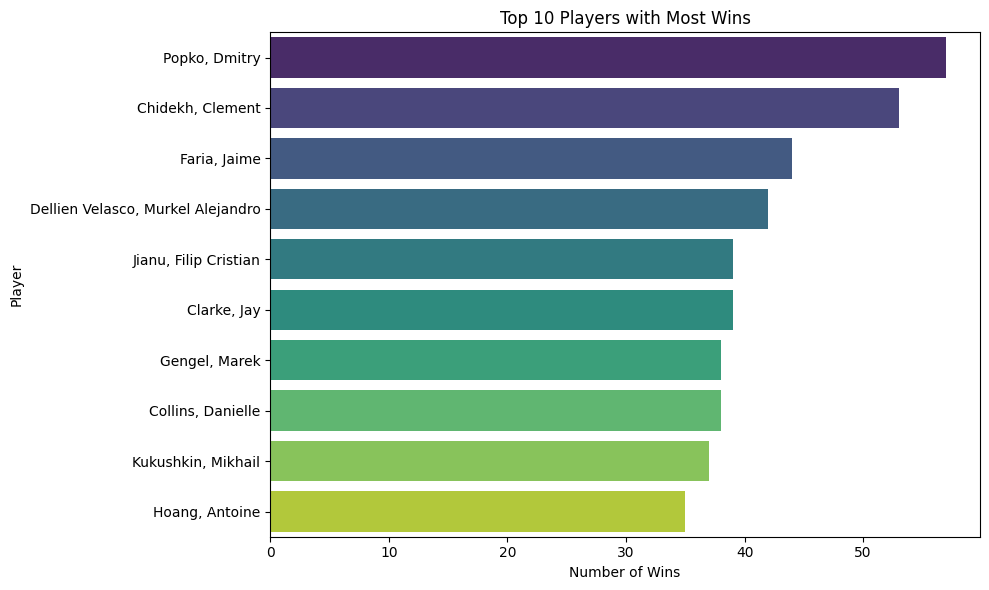

In [59]:
import pandas as pd
from glob import glob
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

event_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/event*.parquet')
home_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/home_team*.parquet')
away_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/away_team*.parquet')

id_to_name = {}
wins = []

for event_file in tqdm(event_files):
    try:
        df_event = pd.read_parquet(event_file, columns=['match_id', 'winner_code'])
        if df_event.empty: continue

        match_id = str(df_event['match_id'].iloc[0])
        winner_code = df_event['winner_code'].iloc[0]

        if winner_code not in [1, 2]:
            continue

        home_file = next((f for f in home_files if match_id in f), None)
        away_file = next((f for f in away_files if match_id in f), None)
        if not home_file or not away_file:
            continue

        df_home = pd.read_parquet(home_file, columns=['player_id', 'full_name'])
        df_away = pd.read_parquet(away_file, columns=['player_id', 'full_name'])

        home_player = df_home.iloc[0]
        away_player = df_away.iloc[0]

        if winner_code == 1:
            winner = home_player
        else:
            winner = away_player

        player_id = winner['player_id']
        player_name = winner['full_name']
        id_to_name[player_id] = player_name
        wins.append(player_id)

    except:
        continue

if wins:
    top_player_id = pd.Series(wins).value_counts().idxmax()
    print("Player with most wins:", id_to_name.get(top_player_id, 'Unknown'))
else:
    print("No wins found.")

win_counts = pd.Series(wins).value_counts()
win_names = win_counts.rename(index=lambda pid: id_to_name.get(pid, 'Unknown'))

top_winners = win_names.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_winners.values, y=top_winners.index, hue=top_winners.index, dodge=False, legend=False, palette='viridis')
plt.title("Top 10 Players with Most Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Player")
plt.tight_layout()
plt.show()


5. How many sets are typically played in a tennis match?

In [ ]:
import pandas as pd
import os

folder_path = '../data/input/tennis_data/20240201/data/raw/raw_match_parquet'  # مسیر پوشه‌ت رو بزار اینجا
files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.parquet')]

target_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
files_with_all_periods = []

for file in files:
    try:
        df = pd.read_parquet(file, engine='pyarrow')
        if all(col in df.columns for col in target_cols):
            files_with_all_periods.append(file)
    except Exception as e:
        print(f'خطا در فایل {file}: {e}')

import pandas as pd

period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
total_sets = []
total_matches = 0

for file in files_with_all_periods:
    df = pd.read_parquet(file, engine='pyarrow')
    
    if df[period_cols].notna().sum(axis=1).sum() == 0:
        continue

    df['sets_played'] = df[period_cols].notna().sum(axis=1)
    total_sets.extend(df['sets_played'].tolist())
    total_matches += len(df)

if total_sets:
    avg_sets = sum(total_sets) / len(total_sets)
    print(f' Average number of sets played across {len(total_sets)} matches: {avg_sets:.2f}')
else:
    print('هیچ مسابقه‌ای با اطلاعات ست معتبر پیدا نشد.')

🎾 Average number of sets played across 818 matches: 2.34


7. What is the average number of aces per match?

In [ ]:
import pandas as pd
import pyarrow.parquet as pq
from glob import glob
from tqdm import tqdm

period_files = glob('../data/input/tennis_data/2024*/data/raw/raw_statistics_parquet/*.parquet')

total_aces = []
match_ids = set()

for file in tqdm(period_files):
    try:
        df = pd.read_parquet(file)

        aces_df = df[df['statistic_name'] == 'aces']

        grouped = aces_df.groupby('match_id')[['home_value', 'away_value']].sum()

        grouped['total_aces'] = grouped['home_value'] + grouped['away_value']

        total_aces.extend(grouped['total_aces'].tolist())

    except Exception as e:
        print(f"Error processing {file}: {e}")

if total_aces:
    average_aces = pd.Series(total_aces).dropna().mean()
    print(f"\n Average number of aces per match: {average_aces:.2f}")
else:
    print("No ace data found.")

100%|██████████| 23291/23291 [03:09<00:00, 123.21it/s]


🎾 Average number of aces per match: 10.59


10. Is there a correlation between a player's height and their ranking?

100%|██████████| 120030/120030 [03:58<00:00, 503.17it/s] 


Correlation between height and current rank: 0.08


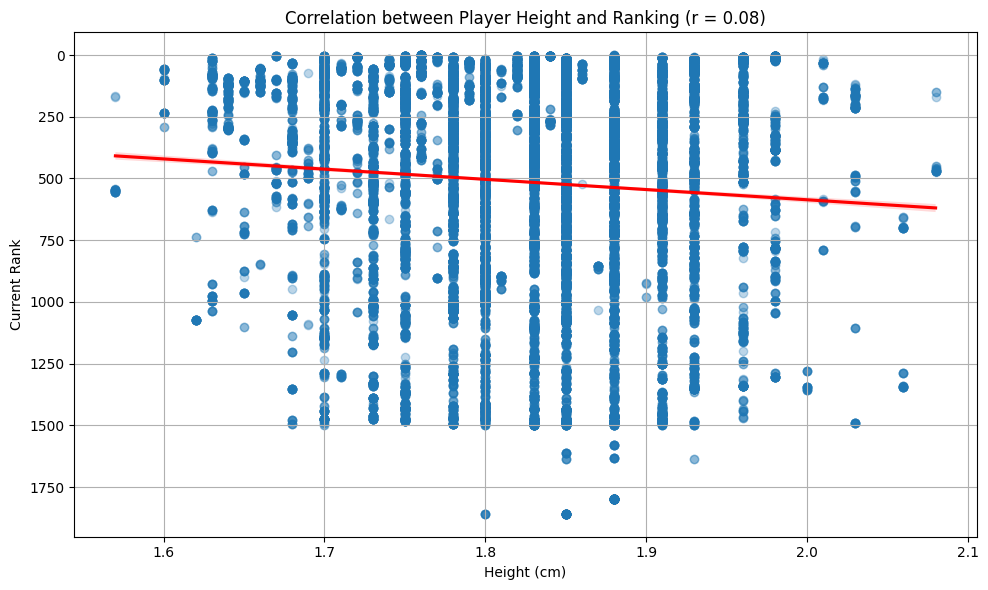

In [ ]:
away_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/away*.parquet')
home_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/home*.parquet')
all_files = away_files + home_files

heights = []
ranks = []

for file in tqdm(all_files):
    try:
        parquet_file = pq.ParquetFile(file)
        column_names = parquet_file.schema.names

        if 'height' in column_names and 'current_rank' in column_names:
            df = pd.read_parquet(file, columns=['height', 'current_rank'])

            df = df.dropna(subset=['height', 'current_rank'])

            heights.extend(df['height'].tolist())
            ranks.extend(df['current_rank'].tolist())

    except Exception as e:
        print(f"Error reading file {file}: {e}")

df = pd.DataFrame({
    'height': heights,
    'current_rank': ranks
})

correlation = df["height"].corr(df["current_rank"])
print(f"Correlation between height and current rank: {correlation:.2f}")

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'height': heights,
    'current_rank': ranks
})

df = df.dropna(subset=['height', 'current_rank'])

correlation = df["height"].corr(df["current_rank"])

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='height', y='current_rank', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlation between Player Height and Ranking (r = {correlation:.2f})')
plt.xlabel('Height (cm)')
plt.ylabel('Current Rank')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

13. What is the distribution of left-handed versus right-handed players? 

Processing files: 100%|██████████| 59256/59256 [01:07<00:00, 879.10it/s] 
C:\Users\SAJEDEH\AppData\Local\Temp\ipykernel_28564\365041568.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



✅ Number of players by playing hand:
right-handed: 10494
left-handed: 1465

✅ Percentage of players by playing hand:
right-handed: 87.75%
left-handed: 12.25%


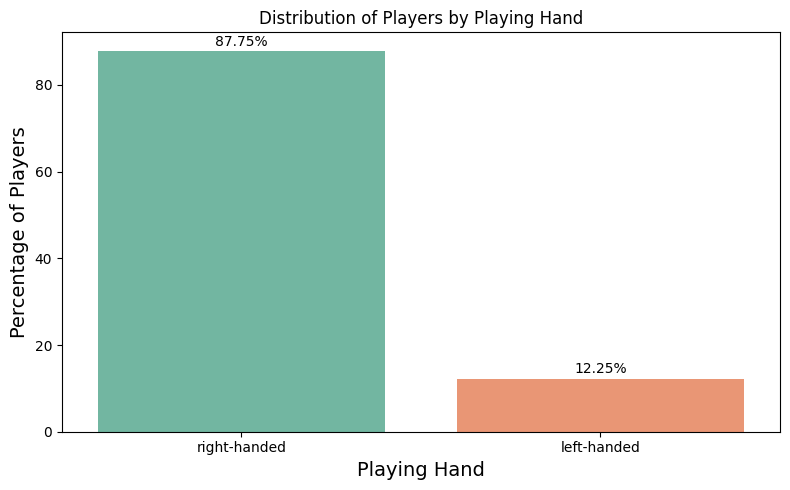

In [57]:
import os
import pandas as pd
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

folder_path = r"..\data\input\tennis_data"

def list_away_team_files(path):
    return [
        os.path.join(root, file)
        for root, _, files in os.walk(path)
        for file in files
        if file.endswith(".parquet") and "away_team" in file
    ]

def process_file(file_path):
    try:
        df = pd.read_parquet(file_path, columns=["plays"])
        return Counter(df["plays"].dropna())
    except:
        return Counter()

def main():
    files = list_away_team_files(folder_path)
    all_counts = Counter()

    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(process_file, f): f for f in files}
        for f in tqdm(as_completed(futures), total=len(futures), desc="Processing files"):
            all_counts += f.result()

    total = sum(all_counts.values())
    percentages = {k: round((v / total) * 100, 2) for k, v in all_counts.items()}

    print("\n✅ Number of players by playing hand:")
    for k, v in all_counts.items():
        print(f"{k}: {v}")

    print("\n✅ Percentage of players by playing hand:")
    for k, v in percentages.items():
        print(f"{k}: {v}%")

    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=list(percentages.keys()),
        y=list(percentages.values()),
        palette="Set2"
    )
    plt.title("Distribution of Players by Playing Hand")
    plt.xlabel("Playing Hand", fontsize=14)
    plt.ylabel("Percentage of Players", fontsize=14)
    for i, v in enumerate(percentages.values()):
        plt.text(i, v + 0.5, f"{v}%", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

main()

16. Which player has the highest winning percentage against top 10 ranked opponents? 

In [ ]:
import pandas as pd
import pyarrow.parquet as pq
from glob import glob
from tqdm import tqdm
from collections import defaultdict

event_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/event_*.parquet')
home_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/home_team_*.parquet')
away_files = glob('../data/input/tennis_data/2024*/data/raw/raw_match_parquet/away_team_*.parquet')

winner_map = {}
for file in tqdm(event_files, desc="Loading winners"):
    try:
        df = pd.read_parquet(file, columns=['match_id', 'winner_code'])
        for _, row in df.iterrows():
            winner_map[row['match_id']] = row['winner_code']
    except Exception as e:
        print(f"Error reading event file {file}: {e}")

player_stats = defaultdict(lambda: {'wins': 0, 'total': 0})

for home_file, away_file in tqdm(zip(home_files, away_files), total=len(home_files), desc="Processing matches"):
    try:
        home_df = pd.read_parquet(home_file)
        away_df = pd.read_parquet(away_file)

        if home_df.empty or away_df.empty:
            continue

        home = home_df.iloc[0]
        away = away_df.iloc[0]

        required_columns = ['match_id', 'player_id', 'current_rank']
        if not all(col in home and col in away for col in required_columns):
            continue

        match_id = home['match_id']
        if match_id not in winner_map:
            continue

        winner_code = winner_map[match_id]

        home_id = home['player_id']
        away_id = away['player_id']
        home_rank = home['current_rank']
        away_rank = away['current_rank']

        if pd.isna(home_rank) or pd.isna(away_rank):
            continue

        if away_rank <= 10:
            player_stats[home_id]['total'] += 1
            if winner_code == 1:
                player_stats[home_id]['wins'] += 1

        if home_rank <= 10:
            player_stats[away_id]['total'] += 1
            if winner_code == 2:
                player_stats[away_id]['wins'] += 1

    except Exception as e:
        print(f"Error processing match {home_file} and {away_file}: {e}")

results = []
for player_id, stats in player_stats.items():
    if stats['total'] > 0:
        win_pct = stats['wins'] / stats['total']
        results.append((player_id, win_pct, stats['wins'], stats['total']))

if results:
    best = max(results, key=lambda x: x[1])
    print(f"Player ID {best[0]} has the highest winning percentage "
          f"against top 10 opponents: {best[1]*100:.2f}% "
          f"({best[2]} wins out of {best[3]} matches)")
else:
    print("No valid data found to calculate statistics.")


Processing matches:  98%|█████████▊| 59256/60774 [09:41<00:14, 101.90it/s]

Player ID 19957 has the highest winning percentage against top 10 opponents: 100.00% (2 wins out of 2 matches)
